In [1]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)

PROJECT = Path('/Users/user/Desktop/ML-Projects/polymarket-trading')
DATA = PROJECT / 'data'
MODELS = DATA / 'models'
FEATURES = DATA / 'features'
PROCESSED = DATA / 'processed'

AFML_PATH = str(Path('../../..').resolve() / 'ml-resources' / 'code' / 'finance_ml_afml')
sys.path.insert(0, AFML_PATH)

print('Setup complete')

Setup complete


In [2]:
prices = pd.read_parquet(PROCESSED / 'prices.parquet')
trades = pd.read_parquet(PROCESSED / 'trades.parquet')
markets = pd.read_parquet(PROCESSED / 'markets.parquet')

fm_baseline = pd.read_parquet(FEATURES / 'feature_matrix_v2.parquet')

with open(MODELS / 'model_meta_v2.json') as f:
    meta_v2 = json.load(f)
with open(MODELS / 'model_meta_v1.json') as f:
    meta_v1 = json.load(f)

FEATURES_LIST_BASELINE = meta_v2['features']

print(f'Prices:     {prices.shape}')
print(f'Trades:     {trades.shape} — {trades["asset"].nunique()} unique tokens')
print(f'Markets:    {markets.shape}')
print(f'Baseline FM: {fm_baseline.shape} — {len(FEATURES_LIST_BASELINE)} features')
print(f'  Date range: {fm_baseline["t0"].min()} → {fm_baseline["t0"].max()}')
print(f'  Labels: {fm_baseline["label"].value_counts().to_dict()}')

Prices:     (1681266, 4)
Trades:     (1139171, 20) — 998 unique tokens
Markets:    (50609, 120)
Baseline FM: (43461, 94) — 63 features
  Date range: 2025-12-05 20:00:00+00:00 → 2026-03-05 23:00:00+00:00
  Labels: {-1: 17546, 1: 17537, 0: 8378}


In [3]:
fm_tokens = set(fm_baseline['token_id'].unique())
trades_filtered = trades[trades['asset'].isin(fm_tokens)].copy()
trades_filtered = trades_filtered.sort_values('datetime')

print(f'Trades in FM tokens: {len(trades_filtered):,} ({trades_filtered["asset"].nunique()} tokens)')
print(f'Trades date range: {trades_filtered["datetime"].min()} → {trades_filtered["datetime"].max()}')

fm_min_t0 = fm_baseline['t0'].min()
fm_max_t0 = fm_baseline['t0'].max()
trades_in_range = trades_filtered[
    (trades_filtered['datetime'] >= fm_min_t0 - pd.Timedelta(hours=24)) &
    (trades_filtered['datetime'] <= fm_max_t0)
]
print(f'Trades in FM date range (±24h): {len(trades_in_range):,}')

Trades in FM tokens: 662,544 (590 tokens)
Trades date range: 2025-05-02 16:50:57+00:00 → 2026-03-06 00:48:03+00:00
Trades in FM date range (±24h): 626,172


In [4]:
def compute_volume_features_fast(fm_df, trades_df, windows_hours=[6, 12, 24]):
    """Fast volume features using hourly buckets + cumsum per token.

    1. Aggregate trades into hourly buckets per token
    2. Build cumulative sum arrays per token (indexed by hour)
    3. For each sample t0: window_value = cumsum[t0_hour] - cumsum[t0_hour - window]
    """
    import time
    t_start = time.time()

    tr = trades_df[['asset', 'datetime', 'size', 'price', 'side']].copy()
    tr['dollar_vol'] = tr['size'] * tr['price']
    tr['is_buy'] = (tr['side'] == 'BUY').astype(float)
    tr['price_x_vol'] = tr['price'] * tr['dollar_vol']
    tr['hour'] = tr['datetime'].dt.floor('h').dt.tz_localize(None)

    hourly = tr.groupby(['asset', 'hour']).agg(
        h_count=('size', 'count'),
        h_volume=('dollar_vol', 'sum'),
        h_size_sum=('size', 'sum'),
        h_buy_sum=('is_buy', 'sum'),
        h_price_vol=('price_x_vol', 'sum'),
    ).reset_index()

    print(f'Hourly buckets: {len(hourly):,} rows, {hourly["asset"].nunique()} tokens')

    metrics = ['h_count', 'h_volume', 'h_size_sum', 'h_buy_sum', 'h_price_vol']
    token_cumsums = {}

    for token_id, group in hourly.groupby('asset'):
        group = group.sort_values('hour')
        hours = group['hour'].values
        cumsums = {m: group[m].cumsum().values for m in metrics}
        token_cumsums[token_id] = {'hours': hours, 'cumsums': cumsums}

    print(f'Cumsum dicts built: {len(token_cumsums)} tokens ({time.time()-t_start:.1f}s)')

    samples = fm_df[['token_id', 't0']].copy()

    samples['t0_hour'] = samples['t0'].dt.floor('h').dt.tz_localize(None)

    vol_features = samples[['token_id', 't0']].copy()

    for w in windows_hours:
        suffix = f'{w}h'
        window_td = np.timedelta64(w, 'h')

        counts = np.zeros(len(samples))
        volumes = np.zeros(len(samples))
        avg_sizes = np.full(len(samples), np.nan)
        buy_ratios = np.full(len(samples), np.nan)
        vwaps = np.full(len(samples), np.nan)

        for i, (_, row) in enumerate(samples.iterrows()):
            token_id = row['token_id']
            t0_hour = row['t0_hour']

            cs = token_cumsums.get(token_id)
            if cs is None:
                continue

            hours = cs['hours']
            t0_np = np.datetime64(t0_hour)
            ws_np = t0_np - window_td

            idx_end = np.searchsorted(hours, t0_np, side='right') - 1
            idx_start = np.searchsorted(hours, ws_np, side='right') - 1

            if idx_end < 0:
                continue

            def cumval(metric, idx):
                return cs['cumsums'][metric][idx] if idx >= 0 else 0.0

            tc = cumval('h_count', idx_end) - cumval('h_count', idx_start)
            tv = cumval('h_volume', idx_end) - cumval('h_volume', idx_start)
            ts = cumval('h_size_sum', idx_end) - cumval('h_size_sum', idx_start)
            tb = cumval('h_buy_sum', idx_end) - cumval('h_buy_sum', idx_start)
            tp = cumval('h_price_vol', idx_end) - cumval('h_price_vol', idx_start)

            if tc > 0:
                counts[i] = tc
                volumes[i] = tv
                avg_sizes[i] = ts / tc
                buy_ratios[i] = tb / tc
                vwaps[i] = tp / tv if tv > 0 else np.nan

        vol_features[f'v_count_{suffix}'] = counts
        vol_features[f'v_volume_{suffix}'] = volumes
        vol_features[f'v_avg_size_{suffix}'] = avg_sizes
        vol_features[f'v_buy_ratio_{suffix}'] = buy_ratios
        vol_features[f'v_vwap_{suffix}'] = vwaps

        non_zero = (counts > 0).sum()
        elapsed = time.time() - t_start
        print(f'  Window {w}h: {non_zero}/{len(counts)} have trades ({non_zero/len(counts)*100:.1f}%), {elapsed:.0f}s')

    return vol_features

print(f'Volume feature function defined — 15 features (5 × 3 windows)')
print(f'Samples: {len(fm_baseline):,}')

Volume feature function defined — 15 features (5 × 3 windows)
Samples: 43,461


In [5]:
print('Computing volume features with rolling lookback...')
vol_df = compute_volume_features_fast(fm_baseline, trades)

vol_cols = [c for c in vol_df.columns if c.startswith('v_')]
print(f'\nVolume features: {len(vol_cols)}')
print(f'Non-NaN coverage:')
for c in vol_cols:
    non_nan = vol_df[c].notna().sum()
    print(f'  {c:>20}: {non_nan}/{len(vol_df)} ({non_nan/len(vol_df)*100:.1f}%)')

vol_df.to_parquet(FEATURES / 'volume_features_v3.parquet', index=False)
print(f'\nSaved to volume_features_v3.parquet')

Computing volume features with rolling lookback...


Hourly buckets: 311,433 rows, 998 tokens


Cumsum dicts built: 998 tokens (0.3s)


  Window 6h: 24022/43461 have trades (55.3%), 1s


  Window 12h: 26924/43461 have trades (61.9%), 2s


  Window 24h: 29256/43461 have trades (67.3%), 3s

Volume features: 15
Non-NaN coverage:
            v_count_6h: 43461/43461 (100.0%)
           v_volume_6h: 43461/43461 (100.0%)
         v_avg_size_6h: 24022/43461 (55.3%)
        v_buy_ratio_6h: 24022/43461 (55.3%)
             v_vwap_6h: 24022/43461 (55.3%)
           v_count_12h: 43461/43461 (100.0%)
          v_volume_12h: 43461/43461 (100.0%)
        v_avg_size_12h: 26924/43461 (61.9%)
       v_buy_ratio_12h: 26924/43461 (61.9%)
            v_vwap_12h: 26924/43461 (61.9%)
           v_count_24h: 43461/43461 (100.0%)
          v_volume_24h: 43461/43461 (100.0%)
        v_avg_size_24h: 29256/43461 (67.3%)
       v_buy_ratio_24h: 29256/43461 (67.3%)
            v_vwap_24h: 29256/43461 (67.3%)

Saved to volume_features_v3.parquet


In [6]:
fm_bin = fm_baseline[fm_baseline['label'] != 0].copy()
fm_bin['y'] = (fm_bin['label'] == 1).astype(int)

print(f'Binary samples: {len(fm_bin):,} (TP={fm_bin["y"].sum()}, SL={(fm_bin["y"]==0).sum()})')
print(f'Date range: {fm_bin["t0"].min()} → {fm_bin["t0"].max()}')

Binary samples: 35,083 (TP=17537, SL=17546)
Date range: 2025-12-05 20:00:00+00:00 → 2026-03-05 21:00:00+00:00


In [7]:
vol_cols = [c for c in vol_df.columns if c.startswith('v_')]
fm_new = fm_bin.merge(
    vol_df[['token_id', 't0'] + vol_cols],
    on=['token_id', 't0'],
    how='left'
)

NEW_FEATURES = FEATURES_LIST_BASELINE + vol_cols

print(f'New feature matrix: {fm_new.shape}')
print(f'Features: {len(NEW_FEATURES)} ({len(FEATURES_LIST_BASELINE)} baseline + {len(vol_cols)} volume)')
print(f'\nLabel distribution: {fm_new["y"].value_counts().to_dict()}')

print(f'\nNaN/zero rates for volume features:')
for c in vol_cols:
    nan_rate = fm_new[c].isna().mean()
    zero_rate = (fm_new[c] == 0).mean() if not fm_new[c].isna().all() else 1.0
    print(f'  {c:>20}: NaN={nan_rate*100:.1f}%, Zero={zero_rate*100:.1f}%')

fm_new.to_parquet(FEATURES / 'feature_matrix_v3.parquet', index=False)
print(f'\nSaved feature_matrix_v3.parquet: {fm_new.shape}')

New feature matrix: (35083, 110)
Features: 78 (63 baseline + 15 volume)

Label distribution: {0: 17546, 1: 17537}

NaN/zero rates for volume features:
            v_count_6h: NaN=0.0%, Zero=45.1%
           v_volume_6h: NaN=0.0%, Zero=45.1%
         v_avg_size_6h: NaN=45.1%, Zero=0.0%
        v_buy_ratio_6h: NaN=45.1%, Zero=8.0%
             v_vwap_6h: NaN=45.1%, Zero=0.0%
           v_count_12h: NaN=0.0%, Zero=38.5%
          v_volume_12h: NaN=0.0%, Zero=38.5%
        v_avg_size_12h: NaN=38.5%, Zero=0.0%
       v_buy_ratio_12h: NaN=38.5%, Zero=6.7%
            v_vwap_12h: NaN=38.5%, Zero=0.0%
           v_count_24h: NaN=0.0%, Zero=33.2%
          v_volume_24h: NaN=0.0%, Zero=33.2%
        v_avg_size_24h: NaN=33.2%, Zero=0.0%
       v_buy_ratio_24h: NaN=33.2%, Zero=4.5%
            v_vwap_24h: NaN=33.2%, Zero=0.0%

Saved feature_matrix_v3.parquet: (35083, 110)


In [8]:
import xgboost as xgb
import lightgbm as lgb

df_model = fm_new.sort_values('t0').reset_index(drop=True)
n = len(df_model)
n_train = int(n * 0.70)
n_val = int(n * 0.15)

train = df_model.iloc[:n_train]
val = df_model.iloc[n_train:n_train+n_val]
test = df_model.iloc[n_train+n_val:]

y_col = 'y'

print(f'Train: {len(train)} ({train["t0"].min().date()} → {train["t0"].max().date()}) — TP:{(train[y_col]==1).sum()}, SL:{(train[y_col]==0).sum()}')
print(f'Val:   {len(val)} ({val["t0"].min().date()} → {val["t0"].max().date()}) — TP:{(val[y_col]==1).sum()}, SL:{(val[y_col]==0).sum()}')
print(f'Test:  {len(test)} ({test["t0"].min().date()} → {test["t0"].max().date()}) — TP:{(test[y_col]==1).sum()}, SL:{(test[y_col]==0).sum()}')

train_medians_new = np.array([train[f].median() for f in NEW_FEATURES])

def prepare_X_new(data):
    X = data[NEW_FEATURES].values.copy().astype(np.float64)
    for j in range(X.shape[1]):
        mask = np.isnan(X[:, j])
        if mask.any():
            med = train_medians_new[j]
            X[mask, j] = med if not np.isnan(med) else 0.0
    return X

X_train = prepare_X_new(train)
X_val = prepare_X_new(val)
X_test = prepare_X_new(test)
y_train = train[y_col].values
y_val = val[y_col].values
y_test = test[y_col].values

print(f'\nFeature shapes: train={X_train.shape}, val={X_val.shape}, test={X_test.shape}')

Train: 24558 (2025-12-05 → 2026-02-06) — TP:12254, SL:12304
Val:   5262 (2026-02-06 → 2026-02-22) — TP:2633, SL:2629
Test:  5263 (2026-02-22 → 2026-03-05) — TP:2650, SL:2613



Feature shapes: train=(24558, 78), val=(5262, 78), test=(5263, 78)


In [9]:
with open(MODELS / 'xgb_best_params.json') as f:
    xgb_params = json.load(f)
with open(MODELS / 'lgb_best_params.json') as f:
    lgb_params = json.load(f)

xgb_model_v3 = xgb.XGBClassifier(**xgb_params, random_state=SEED, eval_metric='logloss')
xgb_model_v3.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

xgb_pred_val = xgb_model_v3.predict_proba(X_val)[:, 1]
xgb_pred_test = xgb_model_v3.predict_proba(X_test)[:, 1]

print('=== XGBoost v3 (baseline + volume features) ===')
print(f'Val  AUC: {roc_auc_score(y_val, xgb_pred_val):.4f}, Brier: {brier_score_loss(y_val, xgb_pred_val):.4f}')
print(f'Test AUC: {roc_auc_score(y_test, xgb_pred_test):.4f}, Brier: {brier_score_loss(y_test, xgb_pred_test):.4f}')

lgb_model_v3 = lgb.LGBMClassifier(**lgb_params, random_state=SEED, verbose=-1)
lgb_model_v3.fit(X_train, y_train, eval_set=[(X_val, y_val)])

lgb_pred_val = lgb_model_v3.predict_proba(X_val)[:, 1]
lgb_pred_test = lgb_model_v3.predict_proba(X_test)[:, 1]

print(f'\n=== LightGBM v3 (baseline + volume features) ===')
print(f'Val  AUC: {roc_auc_score(y_val, lgb_pred_val):.4f}, Brier: {brier_score_loss(y_val, lgb_pred_val):.4f}')
print(f'Test AUC: {roc_auc_score(y_test, lgb_pred_test):.4f}, Brier: {brier_score_loss(y_test, lgb_pred_test):.4f}')

print(f'\n--- Baseline (nb08, 63 features) ---')
print(f'LGB Test AUC: 0.6780, Brier: 0.2267')

=== XGBoost v3 (baseline + volume features) ===
Val  AUC: 0.6987, Brier: 0.2200
Test AUC: 0.6737, Brier: 0.2280



=== LightGBM v3 (baseline + volume features) ===
Val  AUC: 0.6978, Brier: 0.2204
Test AUC: 0.6764, Brier: 0.2270

--- Baseline (nb08, 63 features) ---
LGB Test AUC: 0.6780, Brier: 0.2267


=== Calibrated (Platt) on Test Set ===
XGB Platt: AUC=0.6737, Brier=0.2276
LGB Platt: AUC=0.6764, Brier=0.2269

Top 20 features (LGB v3):
                      p_ret_168h:   750
                ob_vol_liq_ratio:   553
                      ob_bestBid:   506
                    ob_volumeNum:   488
                       p_ret_12h:   421
                        p_ret_1h:   415
                 ob_liquidityNum:   414
                       p_ret_48h:   403
                   p_zscore_168h:   402
               p_price_extremity:   402
                      ob_bestAsk:   401
                 r_kurtosis_168h:   388
                  p_acceleration:   381
                   ob_spread_pct:   379
                         p_price:   378
                    r_vol_regime:   376
                          p_macd:   371
                     ob_midpoint:   370
              r_realized_vol_24h:   365
                        p_rsi_14:   357


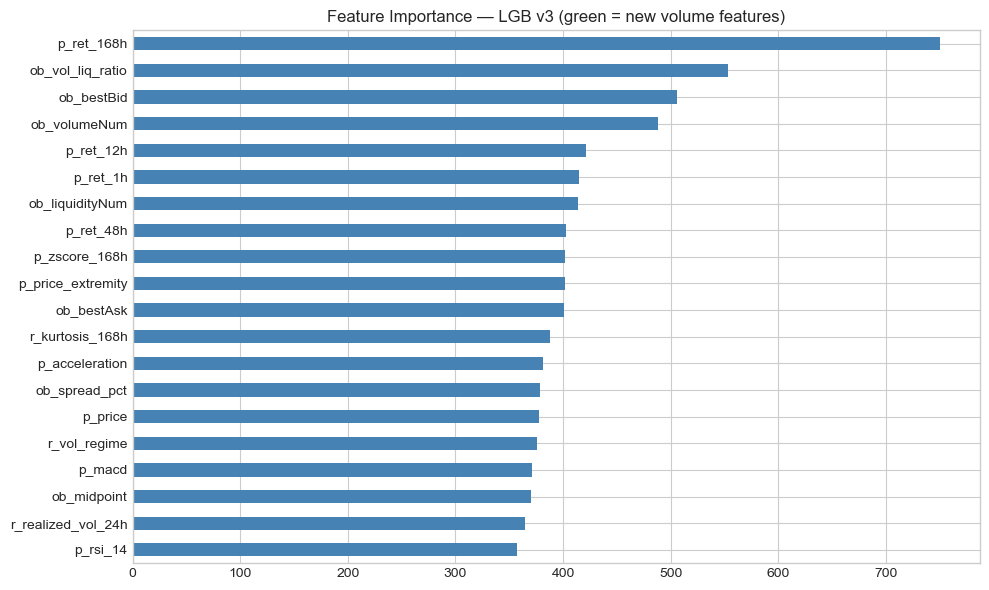

In [10]:
xgb_platt = LogisticRegression()
xgb_platt.fit(xgb_pred_val.reshape(-1, 1), y_val)
xgb_cal_test = xgb_platt.predict_proba(xgb_pred_test.reshape(-1, 1))[:, 1]

lgb_platt = LogisticRegression()
lgb_platt.fit(lgb_pred_val.reshape(-1, 1), y_val)
lgb_cal_test = lgb_platt.predict_proba(lgb_pred_test.reshape(-1, 1))[:, 1]

print('=== Calibrated (Platt) on Test Set ===')
print(f'XGB Platt: AUC={roc_auc_score(y_test, xgb_cal_test):.4f}, Brier={brier_score_loss(y_test, xgb_cal_test):.4f}')
print(f'LGB Platt: AUC={roc_auc_score(y_test, lgb_cal_test):.4f}, Brier={brier_score_loss(y_test, lgb_cal_test):.4f}')

importances = lgb_model_v3.feature_importances_
feat_imp = pd.Series(importances, index=NEW_FEATURES).sort_values(ascending=False)
print(f'\nTop 20 features (LGB v3):')
for feat, imp in feat_imp.head(20).items():
    marker = ' ★ NEW' if feat.startswith('v_') else ''
    print(f'  {feat:>30}: {imp:>5}{marker}')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if f.startswith('v_') else 'steelblue' for f in feat_imp.head(20).index]
feat_imp.head(20).plot.barh(ax=ax, color=colors)
ax.set_title('Feature Importance — LGB v3 (green = new volume features)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

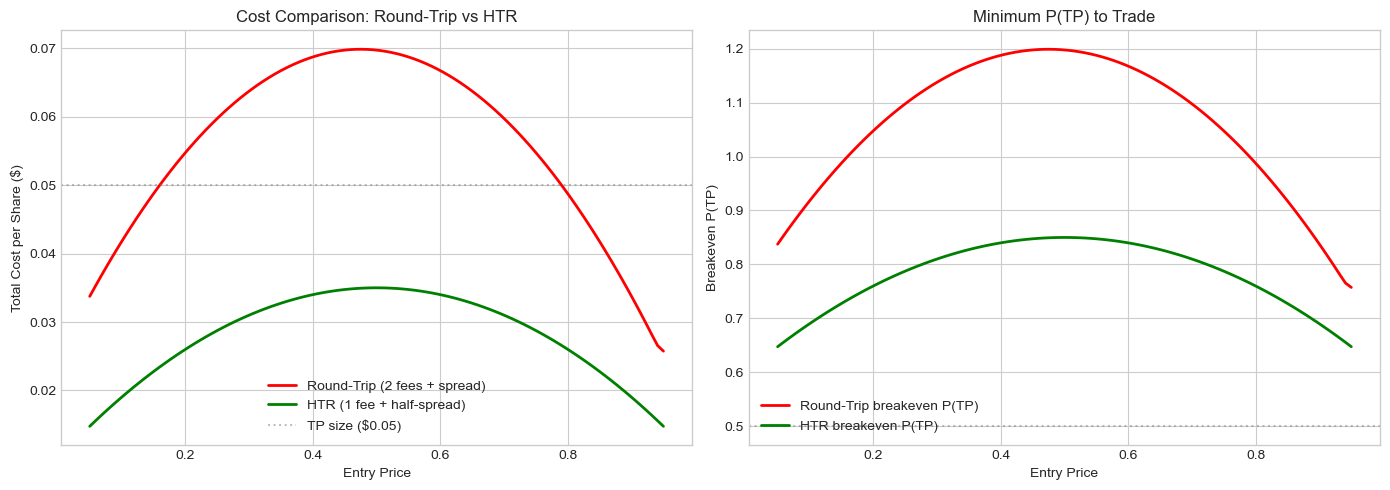

 Price |  RT Cost | HTR Cost |   Save |  RT BE | HTR BE
-------------------------------------------------------
  0.10 | $ 0.0418 | $ 0.0190 |   54% | 91.8% | 69.0%
  0.20 | $ 0.0548 | $ 0.0260 |   53% | 104.8% | 76.0%
  0.30 | $ 0.0638 | $ 0.0310 |   51% | 113.8% | 81.0%
  0.40 | $ 0.0688 | $ 0.0340 |   51% | 118.8% | 84.0%
  0.50 | $ 0.0698 | $ 0.0350 |   50% | 119.8% | 85.0%
  0.60 | $ 0.0668 | $ 0.0340 |   49% | 116.8% | 84.0%
  0.70 | $ 0.0598 | $ 0.0310 |   48% | 109.8% | 81.0%
  0.80 | $ 0.0487 | $ 0.0260 |   47% | 98.7% | 76.0%
  0.90 | $ 0.0337 | $ 0.0190 |   44% | 83.7% | 69.0%


In [11]:
FEE_RATE = 0.10
SPREAD = 0.02
TP_SIZE = 0.05
SL_SIZE = 0.05

def htr_fee(price):
    """Entry fee only."""
    p = np.clip(price, 0.01, 0.99)
    return p * (1 - p) * FEE_RATE

def htr_entry_cost(p_entry, spread=SPREAD):
    """Total entry cost per share (1 fee + half spread)."""
    return htr_fee(p_entry) + spread / 2

def htr_ev(p_model, p_market, spread=SPREAD):
    """Expected value per share with HTR cost model.

    Win: TP_SIZE - entry_cost
    Loss: SL_SIZE + entry_cost
    """
    cost = htr_entry_cost(p_market, spread)
    win_net = TP_SIZE - cost
    loss_net = SL_SIZE + cost

    ev = p_model * win_net - (1 - p_model) * loss_net
    return ev, win_net, loss_net

def rt_ev(p_model, p_market, spread=SPREAD):
    """Expected value with round-trip cost (nb10 baseline)."""
    fee_entry = htr_fee(p_market)
    fee_exit_tp = htr_fee(min(0.99, p_market + TP_SIZE))
    fee_exit_sl = htr_fee(max(0.01, p_market - SL_SIZE))

    win_net = TP_SIZE - fee_entry - fee_exit_tp - spread
    loss_net = SL_SIZE + fee_entry + fee_exit_sl + spread

    ev = p_model * win_net - (1 - p_model) * loss_net
    return ev, win_net, loss_net

prices_range = np.linspace(0.05, 0.95, 100)
rt_costs = [htr_fee(p) + htr_fee(min(0.99, p+TP_SIZE)) + SPREAD for p in prices_range]
htr_costs = [htr_entry_cost(p) for p in prices_range]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(prices_range, rt_costs, 'r-', linewidth=2, label='Round-Trip (2 fees + spread)')
axes[0].plot(prices_range, htr_costs, 'g-', linewidth=2, label='HTR (1 fee + half-spread)')
axes[0].axhline(y=TP_SIZE, color='gray', linestyle=':', alpha=0.5, label=f'TP size (${TP_SIZE})')
axes[0].set_xlabel('Entry Price')
axes[0].set_ylabel('Total Cost per Share ($)')
axes[0].set_title('Cost Comparison: Round-Trip vs HTR')
axes[0].legend()

be_rt = [(SL_SIZE + c) / (TP_SIZE + SL_SIZE) for c in rt_costs]
htr_be = []
for p in prices_range:
    _, wn, ln = htr_ev(0.5, p)
    be = ln / (wn + ln) if (wn + ln) > 0 else 1.0
    htr_be.append(be)

axes[1].plot(prices_range, be_rt, 'r-', linewidth=2, label='Round-Trip breakeven P(TP)')
axes[1].plot(prices_range, htr_be, 'g-', linewidth=2, label='HTR breakeven P(TP)')
axes[1].axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Entry Price')
axes[1].set_ylabel('Breakeven P(TP)')
axes[1].set_title('Minimum P(TP) to Trade')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'{"Price":>6} | {"RT Cost":>8} | {"HTR Cost":>8} | {"Save":>6} | {"RT BE":>6} | {"HTR BE":>6}')
print('-' * 55)
for p in [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]:
    rtc = htr_fee(p) + htr_fee(min(0.99, p+TP_SIZE)) + SPREAD
    htrc = htr_entry_cost(p)
    _, wn, ln = htr_ev(0.5, p)
    be = ln / (wn + ln) if (wn + ln) > 0 else 1.0
    be_r = (SL_SIZE + rtc) / (TP_SIZE + SL_SIZE)
    print(f'{p:6.2f} | ${rtc:7.4f} | ${htrc:7.4f} | {(rtc-htrc)/rtc*100:4.0f}% | {be_r:5.1%} | {be:5.1%}')

In [12]:
def simulate_htr(probs, prices, labels, edge_threshold=0.0,
                 kelly_frac=0.5, max_pos=0.10, initial_bankroll=1000.0):
    """Simulate trades with HTR cost model (1 fee only).

    probs: P(TP) from model
    prices: entry market price
    labels: actual outcome (1=TP, 0=SL)
    """
    bankroll = initial_bankroll
    equity_curve = [bankroll]
    trades = []

    for i in range(len(probs)):
        p_model = probs[i]
        p_market = prices[i]
        actual = labels[i]

        ev, win_net, loss_net = htr_ev(p_model, p_market)

        if ev <= edge_threshold or win_net <= 0:
            equity_curve.append(bankroll)
            continue

        b = win_net / loss_net
        q = 1 - p_model
        f = (p_model * b - q) / b
        f = max(0, f) * kelly_frac
        pos_frac = min(f, max_pos)

        if pos_frac <= 0:
            equity_curve.append(bankroll)
            continue

        bet_size = bankroll * pos_frac
        n_shares = bet_size / p_market
        entry_cost = htr_entry_cost(p_market) * n_shares

        if actual == 1:
            net_pnl = win_net * n_shares
        else:
            net_pnl = -loss_net * n_shares

        bankroll += net_pnl

        trades.append({
            'p_model': p_model, 'p_market': p_market, 'ev': ev,
            'pos_frac': pos_frac, 'bet_size': bet_size, 'n_shares': n_shares,
            'actual': actual, 'win_net': win_net, 'loss_net': loss_net,
            'entry_cost': entry_cost, 'net_pnl': net_pnl, 'bankroll': bankroll,
        })
        equity_curve.append(bankroll)

    return trades, equity_curve

def compute_htr_metrics(trades, equity_curve, initial_bankroll=1000.0):
    if len(trades) == 0:
        return {k: 0 if k == 'n_trades' else 0.0 for k in [
            'n_trades', 'total_pnl', 'total_pnl_pct', 'win_rate',
            'sharpe', 'max_dd', 'avg_pnl', 'avg_pos_frac', 'total_costs', 'cost_pct']}

    df_t = pd.DataFrame(trades)
    total_pnl = df_t['net_pnl'].sum()
    returns = df_t['net_pnl'] / df_t['bet_size']

    eq = np.array(equity_curve)
    peak = np.maximum.accumulate(eq)
    dd = (peak - eq) / peak

    total_costs = df_t['entry_cost'].sum()
    gross = total_pnl + total_costs

    return {
        'n_trades': len(trades),
        'total_pnl': total_pnl,
        'total_pnl_pct': total_pnl / initial_bankroll * 100,
        'win_rate': (df_t['net_pnl'] > 0).mean(),
        'sharpe': returns.mean() / returns.std() if returns.std() > 0 else 0,
        'max_dd': dd.max(),
        'avg_pnl': df_t['net_pnl'].mean(),
        'avg_pos_frac': df_t['pos_frac'].mean(),
        'total_costs': total_costs,
        'cost_pct': total_costs / abs(gross) if gross != 0 else 0,
    }

print('HTR simulation functions defined')

HTR simulation functions defined


In [13]:
val_prices_arr = val['p_price'].values
val_lgb_raw = lgb_model_v3.predict_proba(X_val)[:, 1]
val_lgb_cal = lgb_platt.predict_proba(val_lgb_raw.reshape(-1, 1))[:, 1]

val_ev = np.array([htr_ev(p, m)[0] for p, m in zip(val_lgb_cal, val_prices_arr)])
print(f'HTR EV on validation:')
print(f'  Mean: {val_ev.mean():.6f}, % positive: {(val_ev > 0).mean()*100:.1f}%')
print(f'  Max: {val_ev.max():.6f}, Min: {val_ev.min():.6f}')

val_ev_rt = np.array([rt_ev(p, m)[0] for p, m in zip(val_lgb_cal, val_prices_arr)])
print(f'\nRT EV (baseline) on validation:')
print(f'  Mean: {val_ev_rt.mean():.6f}, % positive: {(val_ev_rt > 0).mean()*100:.1f}%')

thresholds = np.arange(-0.02, 0.05, 0.002)
htr_val_results = []

for th in thresholds:
    trades, eq = simulate_htr(val_lgb_cal, val_prices_arr, y_val,
                              edge_threshold=th, kelly_frac=0.5, max_pos=0.10)
    m = compute_htr_metrics(trades, eq)
    m['threshold'] = th
    htr_val_results.append(m)

df_htr_val = pd.DataFrame(htr_val_results)
print(f'\nThreshold sweep (val):')
print(df_htr_val[['threshold', 'n_trades', 'total_pnl_pct', 'win_rate', 'sharpe', 'max_dd']].to_string(index=False))

HTR EV on validation:
  Mean: -0.030131, % positive: 4.5%
  Max: 0.016194, Min: -0.070365

RT EV (baseline) on validation:
  Mean: -0.060119, % positive: 0.0%



Threshold sweep (val):
    threshold  n_trades  total_pnl_pct  win_rate   sharpe   max_dd
-2.000000e-02       238    1435.830637  0.823529 0.315696 0.145597
-1.800000e-02       238    1435.830637  0.823529 0.315696 0.145597
-1.600000e-02       238    1435.830637  0.823529 0.315696 0.145597
-1.400000e-02       238    1435.830637  0.823529 0.315696 0.145597
-1.200000e-02       238    1435.830637  0.823529 0.315696 0.145597
-1.000000e-02       238    1435.830637  0.823529 0.315696 0.145597
-8.000000e-03       238    1435.830637  0.823529 0.315696 0.145597
-6.000000e-03       238    1435.830637  0.823529 0.315696 0.145597
-4.000000e-03       238    1435.830637  0.823529 0.315696 0.145597
-2.000000e-03       238    1435.830637  0.823529 0.315696 0.145597
-1.734723e-17       238    1435.830637  0.823529 0.315696 0.145597
 2.000000e-03       169    1442.387147  0.869822 0.423310 0.142883
 4.000000e-03       118    1193.210042  0.872881 0.491006 0.142883
 6.000000e-03        72     828.345418

In [14]:
viable = df_htr_val[df_htr_val['n_trades'] >= 20].copy()
if len(viable) > 0:
    best_idx = viable['sharpe'].idxmax()
    best_th = viable.loc[best_idx, 'threshold']
    print(f'Best HTR threshold: {best_th:.4f}')
    print(viable.loc[best_idx].to_string())
else:
    profitable = df_htr_val[df_htr_val['total_pnl_pct'] > 0]
    best_th = profitable.iloc[0]['threshold'] if len(profitable) > 0 else 0.0
    print(f'Fallback threshold: {best_th:.4f}')

test_prices_arr = test['p_price'].values
test_lgb_raw = lgb_model_v3.predict_proba(X_test)[:, 1]
test_lgb_cal = lgb_platt.predict_proba(test_lgb_raw.reshape(-1, 1))[:, 1]

htr_test_trades, htr_test_eq = simulate_htr(
    test_lgb_cal, test_prices_arr, y_test,
    edge_threshold=best_th, kelly_frac=0.5, max_pos=0.10
)
htr_test_m = compute_htr_metrics(htr_test_trades, htr_test_eq)

print(f'\n{"="*50}')
print(f'HTR TEST SET RESULTS')
print(f'{"="*50}')
for k, v in htr_test_m.items():
    print(f'  {k:>20}: {v:.4f}' if isinstance(v, float) else f'  {k:>20}: {v}')
print(f'\nFinal bankroll: ${htr_test_eq[-1]:.2f}')

Best HTR threshold: 0.0100
n_trades           33.000000
total_pnl        5751.479359
total_pnl_pct     575.147936
win_rate            0.969697
sharpe              1.031808
max_dd              0.142883
avg_pnl           174.287253
avg_pos_frac        0.100000
total_costs      2659.749383
cost_pct            0.316214
threshold           0.010000

HTR TEST SET RESULTS
              n_trades: 21
             total_pnl: 1339.2573
         total_pnl_pct: 133.9257
              win_rate: 0.9048
                sharpe: 0.7162
                max_dd: 0.1915
               avg_pnl: 63.7742
          avg_pos_frac: 0.1000
           total_costs: 916.7847
              cost_pct: 0.4064

Final bankroll: $2339.26


In [15]:
def walk_forward_htr(df_data, features, min_train_days=60, test_step_days=7,
                     edge_threshold=0.0, kelly_frac=0.5, max_pos=0.10,
                     initial_bankroll=1000.0):
    """Walk-forward backtest with HTR cost model."""
    df_data = df_data.sort_values('t0').reset_index(drop=True)
    timestamps = df_data['t0']

    t_min, t_max = timestamps.min(), timestamps.max()
    train_end = t_min + pd.Timedelta(days=min_train_days)

    all_trades = []
    bankroll = initial_bankroll
    equity_curve = [bankroll]
    window_metrics = []
    window_num = 0

    local_medians = np.array([df_data[f].median() for f in features])

    while train_end < t_max:
        test_end = train_end + pd.Timedelta(days=test_step_days)

        train_mask = timestamps <= train_end
        test_mask = (timestamps > train_end) & (timestamps <= test_end)

        if test_mask.sum() < 5:
            train_end = test_end
            continue

        df_tr = df_data[train_mask]
        df_te = df_data[test_mask]

        def prep_X(data):
            X = data[features].values.copy().astype(np.float64)
            for j in range(X.shape[1]):
                mask = np.isnan(X[:, j])
                if mask.any():
                    X[mask, j] = local_medians[j] if not np.isnan(local_medians[j]) else 0.0
            return X

        X_tr = prep_X(df_tr)
        y_tr = df_tr['y'].values
        X_te = prep_X(df_te)
        y_te = df_te['y'].values

        model = lgb.LGBMClassifier(**lgb_params, random_state=SEED, verbose=-1)
        model.fit(X_tr, y_tr)

        n_cal = max(50, int(len(X_tr) * 0.2))
        raw_cal = model.predict_proba(X_tr[-n_cal:])[:, 1]
        cal_lr = LogisticRegression()
        cal_lr.fit(raw_cal.reshape(-1, 1), y_tr[-n_cal:])

        raw_te = model.predict_proba(X_te)[:, 1]
        prob_te = cal_lr.predict_proba(raw_te.reshape(-1, 1))[:, 1]

        prices_te = df_te['p_price'].values
        trades_w, eq_w = simulate_htr(
            prob_te, prices_te, y_te,
            edge_threshold=edge_threshold, kelly_frac=kelly_frac, max_pos=max_pos,
            initial_bankroll=bankroll
        )

        if len(trades_w) > 0:
            bankroll = eq_w[-1]
            all_trades.extend(trades_w)
            equity_curve.extend(eq_w[1:])

        w_m = compute_htr_metrics(trades_w, eq_w, eq_w[0] if eq_w else bankroll)
        w_m['window'] = window_num
        w_m['train_end'] = str(train_end.date())
        w_m['test_end'] = str(test_end.date())
        window_metrics.append(w_m)

        window_num += 1
        train_end = test_end

    return all_trades, equity_curve, window_metrics

print('Running HTR walk-forward backtest...')
wf_trades, wf_eq, wf_windows = walk_forward_htr(
    df_model, NEW_FEATURES,
    min_train_days=60, test_step_days=7,
    edge_threshold=best_th, kelly_frac=0.5, max_pos=0.10
)

wf_m = compute_htr_metrics(wf_trades, wf_eq, 1000.0)

print(f'\n{"="*50}')
print(f'HTR WALK-FORWARD RESULTS ({len(wf_windows)} windows)')
print(f'{"="*50}')
for k, v in wf_m.items():
    print(f'  {k:>20}: {v:.4f}' if isinstance(v, float) else f'  {k:>20}: {v}')
print(f'\nFinal bankroll: ${wf_eq[-1]:.2f}')

df_wf = pd.DataFrame(wf_windows)
if len(df_wf) > 0:
    print(f'\nPer-window:')
    print(df_wf[['window', 'train_end', 'test_end', 'n_trades', 'total_pnl_pct', 'win_rate', 'sharpe']].to_string(index=False))

Running HTR walk-forward backtest...



HTR WALK-FORWARD RESULTS (5 windows)
              n_trades: 688
             total_pnl: 240522.9874
         total_pnl_pct: 24052.2987
              win_rate: 0.7936
                sharpe: 0.2495
                max_dd: 0.2713
               avg_pnl: 349.5974
          avg_pos_frac: 0.1000
           total_costs: 487523.0200
              cost_pct: 0.6696

Final bankroll: $241522.99

Per-window:
 window  train_end   test_end  n_trades  total_pnl_pct  win_rate   sharpe
      0 2026-02-03 2026-02-10       138     396.371320  0.804348 0.287832
      1 2026-02-10 2026-02-17       125     417.943228  0.832000 0.380455
      2 2026-02-17 2026-02-24       165     115.133804  0.781818 0.193882
      3 2026-02-24 2026-03-03       238     261.221766  0.768908 0.187482
      4 2026-03-03 2026-03-10        22      20.889078  0.863636 0.236732


In [16]:
with open(MODELS / 'backtest_meta_v1.json') as f:
    baseline_meta = json.load(f)

print('='*70)
print('COMPARISON: Round-Trip (nb10) vs HTR Cost Model (nb11)')
print('='*70)

comparison = pd.DataFrame({
    'Metric': ['Cost model', 'N features', 'Test trades', 'Test PnL %',
               'WF trades', 'WF PnL %', 'WF Win Rate', 'WF Sharpe', 'WF Max DD',
               'WF Costs/Gross'],
    'Baseline nb10': [
        '2 fees (RT)', 63,
        baseline_meta['test_set']['n_trades'],
        f'{baseline_meta["test_set"]["total_pnl_pct"]:.1f}%',
        baseline_meta['walk_forward']['n_trades'],
        f'{baseline_meta["walk_forward"]["total_pnl_pct"]:.1f}%',
        f'{baseline_meta["walk_forward"]["win_rate"]:.1%}',
        f'{baseline_meta["walk_forward"]["sharpe"]:.4f}',
        f'{baseline_meta["walk_forward"]["max_dd"]:.1%}',
        f'{baseline_meta["walk_forward"]["fee_pct_of_gross"]:.1%}',
    ],
    'HTR nb11': [
        '1 fee (HTR)', len(NEW_FEATURES),
        htr_test_m['n_trades'],
        f'{htr_test_m["total_pnl_pct"]:.1f}%',
        wf_m['n_trades'],
        f'{wf_m["total_pnl_pct"]:.1f}%',
        f'{wf_m["win_rate"]:.1%}',
        f'{wf_m["sharpe"]:.4f}',
        f'{wf_m["max_dd"]:.1%}',
        f'{wf_m["cost_pct"]:.1%}',
    ],
})

print(comparison.to_string(index=False))

COMPARISON: Round-Trip (nb10) vs HTR Cost Model (nb11)
        Metric Baseline nb10    HTR nb11
    Cost model   2 fees (RT) 1 fee (HTR)
    N features            63          78
   Test trades             0          21
    Test PnL %          0.0%      133.9%
     WF trades            90         688
      WF PnL %        141.5%    24052.3%
   WF Win Rate         83.3%       79.4%
     WF Sharpe        0.2452      0.2495
     WF Max DD         31.7%       27.1%
WF Costs/Gross         83.9%       67.0%


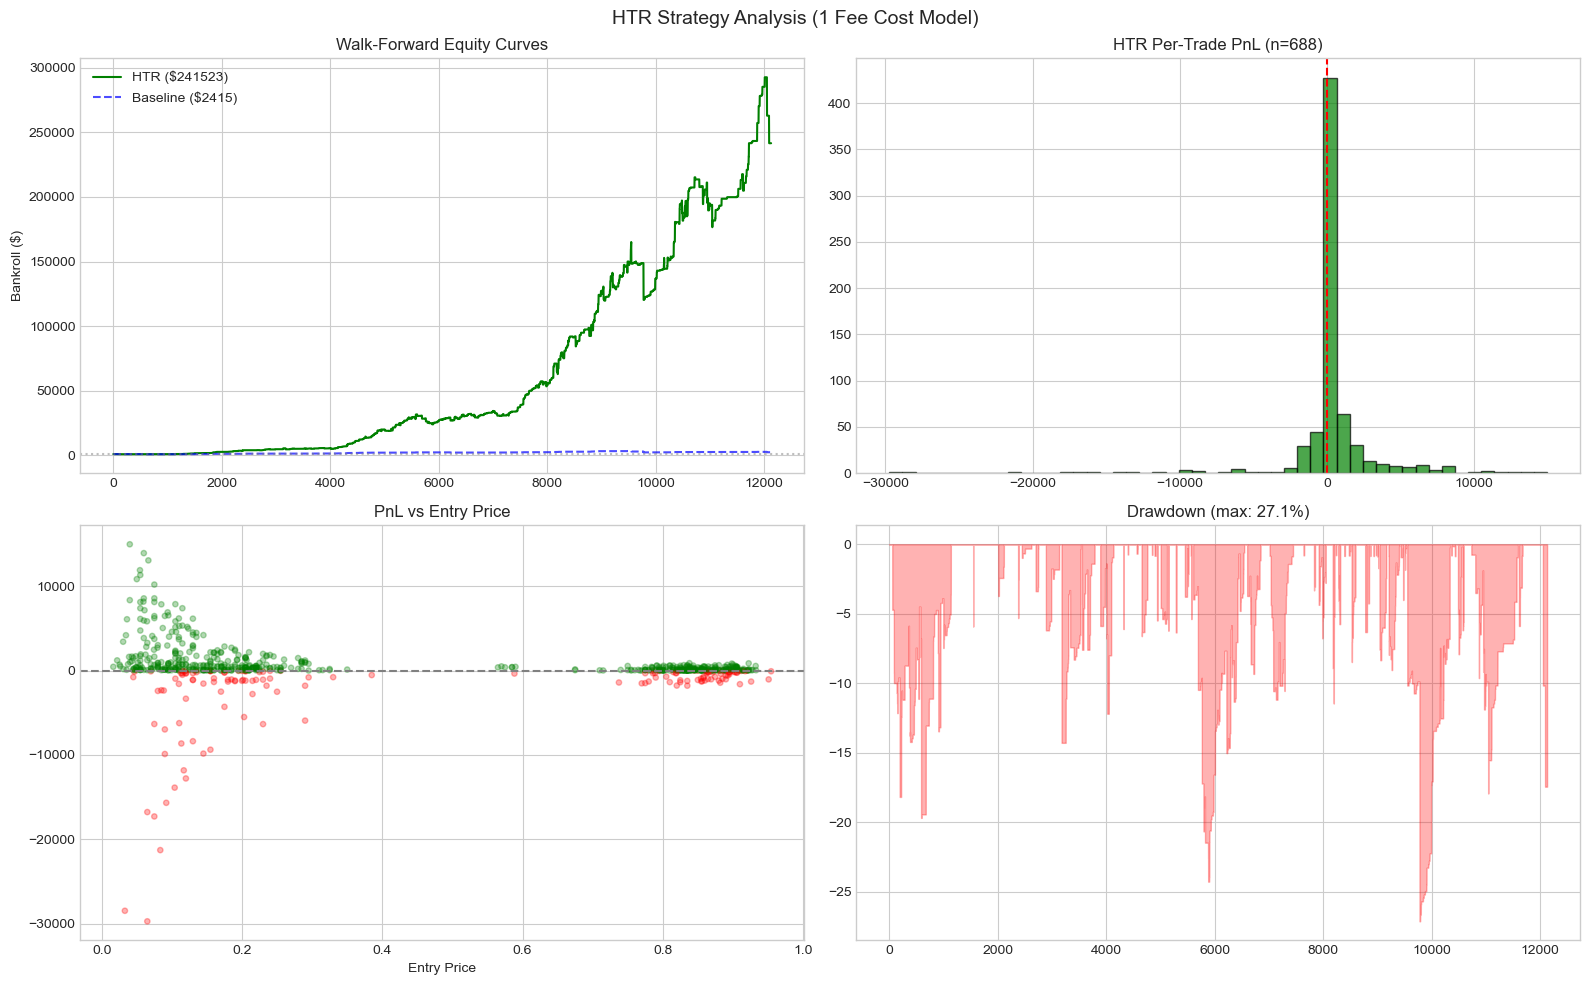

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

if len(wf_eq) > 1:
    axes[0,0].plot(wf_eq, 'g-', linewidth=1.5, label=f'HTR (${wf_eq[-1]:.0f})')
try:
    baseline_eq = pd.read_csv(DATA / 'processed' / 'backtest_equity_v1.csv')['equity'].values
    axes[0,0].plot(baseline_eq, 'b--', linewidth=1.5, alpha=0.7, label=f'Baseline (${baseline_eq[-1]:.0f})')
except:
    pass
axes[0,0].axhline(y=1000, color='gray', linestyle=':', alpha=0.5)
axes[0,0].set_title('Walk-Forward Equity Curves')
axes[0,0].set_ylabel('Bankroll ($)')
axes[0,0].legend()

if len(wf_trades) > 0:
    df_wf_t = pd.DataFrame(wf_trades)

    axes[0,1].hist(df_wf_t['net_pnl'], bins=50, color='green', edgecolor='black', alpha=0.7)
    axes[0,1].axvline(x=0, color='r', linestyle='--')
    axes[0,1].set_title(f'HTR Per-Trade PnL (n={len(df_wf_t)})')

    axes[1,0].scatter(df_wf_t['p_market'], df_wf_t['net_pnl'],
                      c=df_wf_t['actual'].map({1: 'green', 0: 'red'}), alpha=0.3, s=15)
    axes[1,0].axhline(y=0, color='gray', linestyle='--')
    axes[1,0].set_title('PnL vs Entry Price')
    axes[1,0].set_xlabel('Entry Price')

    eq = np.array(wf_eq)
    peak = np.maximum.accumulate(eq)
    dd = (peak - eq) / peak
    axes[1,1].fill_between(range(len(dd)), -dd*100, 0, color='red', alpha=0.3)
    axes[1,1].set_title(f'Drawdown (max: {dd.max():.1%})')
else:
    for ax in [axes[0,1], axes[1,0], axes[1,1]]:
        ax.text(0.5, 0.5, 'No trades', transform=ax.transAxes, ha='center', fontsize=14)

plt.suptitle('HTR Strategy Analysis (1 Fee Cost Model)', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
joblib.dump(lgb_model_v3, MODELS / 'lgb_v3.joblib')
joblib.dump(xgb_model_v3, MODELS / 'xgb_v3.joblib')
joblib.dump({'platt_lgb': lgb_platt, 'platt_xgb': xgb_platt}, MODELS / 'calibrators_v3.joblib')

htr_meta = {
    'strategy': 'htr_cost_model_lgb_platt',
    'features': NEW_FEATURES,
    'n_features': len(NEW_FEATURES),
    'volume_features': vol_cols,
    'edge_threshold': float(best_th),
    'kelly_fraction': 0.5,
    'max_position': 0.10,
    'fee_rate': FEE_RATE,
    'spread': SPREAD,
    'fee_model': '1 fee (entry only)',
    'train_medians': train_medians_new.tolist(),
    'test_set': {k: float(v) if isinstance(v, (float, np.floating)) else int(v) if isinstance(v, (int, np.integer)) else v
                 for k, v in htr_test_m.items()},
    'walk_forward': {
        'n_windows': len(wf_windows),
        **{k: float(v) if isinstance(v, (float, np.floating)) else int(v) if isinstance(v, (int, np.integer)) else v
           for k, v in wf_m.items()},
    },
    'model_metrics': {
        'lgb_test_auc': float(roc_auc_score(y_test, lgb_cal_test)),
        'lgb_test_brier': float(brier_score_loss(y_test, lgb_cal_test)),
        'xgb_test_auc': float(roc_auc_score(y_test, xgb_cal_test)),
        'xgb_test_brier': float(brier_score_loss(y_test, xgb_cal_test)),
    },
    'seed': SEED,
}

with open(MODELS / 'htr_meta_v1.json', 'w') as f:
    json.dump(htr_meta, f, indent=2, default=str)

if len(wf_trades) > 0:
    pd.DataFrame(wf_trades).to_parquet(DATA / 'processed' / 'backtest_htr_trades_v1.parquet', index=False)
pd.Series(wf_eq, name='equity').to_csv(DATA / 'processed' / 'backtest_htr_equity_v1.csv', index=False)

with open(FEATURES / 'feature_meta_v3.json', 'w') as f:
    json.dump({
        'features': NEW_FEATURES,
        'n_features': len(NEW_FEATURES),
        'volume_features': vol_cols,
        'baseline_features': FEATURES_LIST_BASELINE,
    }, f, indent=2)

print('Saved:')
print(f'  Models: lgb_v3, xgb_v3, calibrators_v3')
print(f'  Meta: htr_meta_v1.json, feature_meta_v3.json')
print(f'  Data: feature_matrix_v3.parquet, volume_features_v3.parquet')
print(f'  Backtest: backtest_htr_trades/equity')

print(f'\n{"="*60}')
print(f'NOTEBOOK 11 SUMMARY')
print(f'{"="*60}')
print(f'\n1. Volume Features: {len(vol_cols)} new (rolling lookback 6/12/24h)')
print(f'2. Cost Model: HTR (1 fee) vs RT (2 fees) — ~50% cheaper')
print(f'3. Total Features: {len(NEW_FEATURES)} ({len(FEATURES_LIST_BASELINE)} baseline + {len(vol_cols)} volume)')
print(f'\nModel (LGB v3 + vol features):')
print(f'  Test AUC: {roc_auc_score(y_test, lgb_cal_test):.4f} (baseline: 0.678)')
print(f'  Test Brier: {brier_score_loss(y_test, lgb_cal_test):.4f} (baseline: 0.227)')
print(f'\nBacktest:')
print(f'  Test: {htr_test_m["n_trades"]} trades, {htr_test_m["total_pnl_pct"]:.1f}% (baseline: 0 trades)')
print(f'  WF:   {wf_m["n_trades"]} trades, {wf_m["total_pnl_pct"]:.1f}% (baseline: 90 trades, 141.5%)')
print(f'  WF Sharpe: {wf_m["sharpe"]:.4f} (baseline: 0.2452)')
print(f'  WF Costs: {wf_m["cost_pct"]:.1%} (baseline: 83.9%)')

Saved:
  Models: lgb_v3, xgb_v3, calibrators_v3
  Meta: htr_meta_v1.json, feature_meta_v3.json
  Data: feature_matrix_v3.parquet, volume_features_v3.parquet
  Backtest: backtest_htr_trades/equity

NOTEBOOK 11 SUMMARY

1. Volume Features: 15 new (rolling lookback 6/12/24h)
2. Cost Model: HTR (1 fee) vs RT (2 fees) — ~50% cheaper
3. Total Features: 78 (63 baseline + 15 volume)

Model (LGB v3 + vol features):
  Test AUC: 0.6764 (baseline: 0.678)
  Test Brier: 0.2269 (baseline: 0.227)

Backtest:
  Test: 21 trades, 133.9% (baseline: 0 trades)
  WF:   688 trades, 24052.3% (baseline: 90 trades, 141.5%)
  WF Sharpe: 0.2495 (baseline: 0.2452)
  WF Costs: 67.0% (baseline: 83.9%)
